## Benchmark Comparisons 

Comparing BMO, WOA, and MFO using six standard benchmarking functions

#### Importing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.random.seed(2025)

In [3]:
from WOA import WOA
from BMO import BMO

In [4]:
from benchmarking_functions import sphere, asap, rastrigin, griewank, shc, branin

#### Defining Benchmarking Bounds

In [5]:
# bounds for 6 benchmarking functions

# f1 - sphere bounds
sphere_lb = (-5.12)
sphere_ub = (5.12)

# f2 - asap bounds
asap_lb = (-5.12)
asap_ub = (5.12)

# f3 - rastrigin bounds
rastrigin_lb = (-5.12)
rastrigin_ub = (5.12)

# f4 - griewank bounds
griewank_lb = (-600)
griewank_ub = (600)

# f5 - six hump camel bounds
shc_lb = np.array([-3, -2])
shc_ub = np.array([ 3,  2])

# f6 - branin bounds
branin_lb = np.array([-5,  0])
branin_ub = np.array([10, 15])

In [6]:
# bounds for BMO for 6 benchmarking functions
sphere_bounds    = (-5.12, 5.12)
asap_bounds      = (-5.12, 5.12)
rastrigin_bounds = (-5.12, 5.12)
griewank_bounds  = (-600, 600)
shc_bounds = [(-3, 3), (-2, 2)]
branin_bounds = [(-5, 10), (0, 15)]

#### Running BMO 30 times

In [7]:
def run_multiple_BMO(obj_fn, dim, bounds, runs=30):
    ''' Runs BMO 30 times
    
        Parameters:
            obj_fn: objective function
            dim: dimensions
            bounds: lower and upper bounds
            runs: amount of times ran, set at 30
            
        Returns:
            Mean of best values: average best values 
            Std. Dev. of best values: standard deviation of best values
            best_values: list of best values
            avg_history: average convergence curve
            std_history: standard deviation of convergence curve'''
    
    # store best values and histories
    best_values = []
    histories = []

    # run BMO for the set amount of runs, define parameters
    for r in range(runs):
        best_sol, best_fit, history = BMO(
            obj_fn=obj_fn,
            dim=dim,
            bounds=bounds,
            pop_size=50,
            max_gens=500,
            seed=2025
        )
        # add best values and histories to list as alg runs
        best_values.append(best_fit)
        histories.append(history)

    # convert to array for averaging
    # shape: (runs, max_gens)
    histories = np.array(histories)   

    # take average and std dev across runs
    avg_history = histories.mean(axis=0)
    std_history = histories.std(axis=0)

    return (
        np.mean(best_values), 
        np.std(best_values), 
        best_values,
        avg_history,
        std_history
    )


In [8]:
def evaluate_and_plot(name, func, dim, bounds):
    ''' Returns mean and standard deviation of best values across 30 runs of BMO
    
        Parameters:
            name: name of objective function
            func: objective_function
            dim: dimensionality
            bounds: lower and upper bounds
            
        Returns:
            mean_val: mean value of values
            std_val: standard deviation of values
            convergence plots, one for each objective function'''
    
    # processing.... 
    print(f"\nRunning 30 runs for {name}...")

    # apply run_multiple BMO function 
    mean_val, std_val, runs_vals, avg_hist, std_hist = run_multiple_BMO(
        func, dim, bounds, runs=30
    )

    # printing mean fitness and standard deviation fitness
    print(f"{name} Mean Fitness: {mean_val}")
    print(f"{name} Std Dev     : {std_val}")

    # plot convergence 
    plt.figure(figsize=(7,5))
    plt.plot(avg_hist, label="Average Convergence")
    plt.title(f"BMO Convergence Curve: {name}")
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()



Running 30 runs for Sphere (f1)...
Sphere (f1) Mean Fitness: 4.973610801935041e-07
Sphere (f1) Std Dev     : 1.0587911840678754e-22


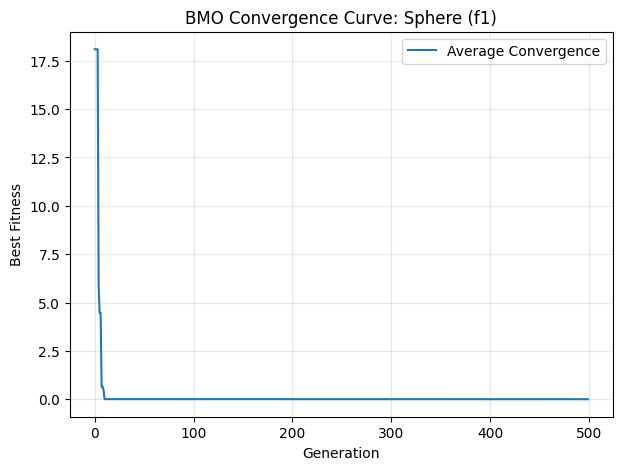


Running 30 runs for Absolute Sum & Absolute Product (f2)...
Absolute Sum & Absolute Product (f2) Mean Fitness: 0.0024311804962626558
Absolute Sum & Absolute Product (f2) Std Dev     : 4.336808689942018e-19


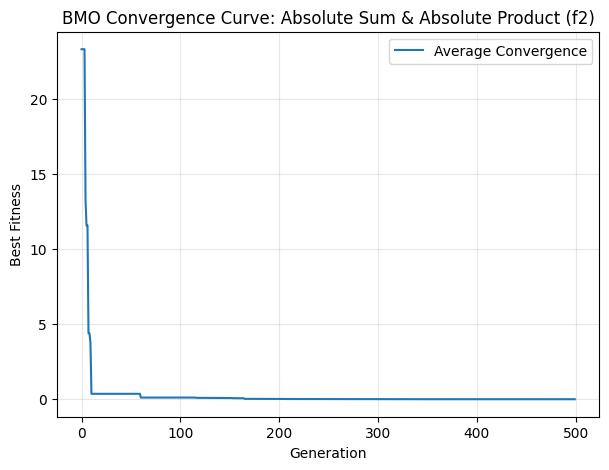


Running 30 runs for Rastrigin (f3)...
Rastrigin (f3) Mean Fitness: 0.00035019712282746696
Rastrigin (f3) Std Dev     : 0.0


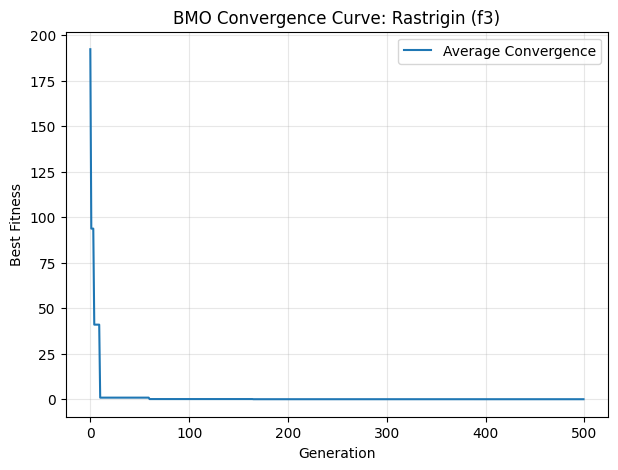


Running 30 runs for Griewank (f4)...
Griewank (f4) Mean Fitness: 0.0004137264541882457
Griewank (f4) Std Dev     : 0.0


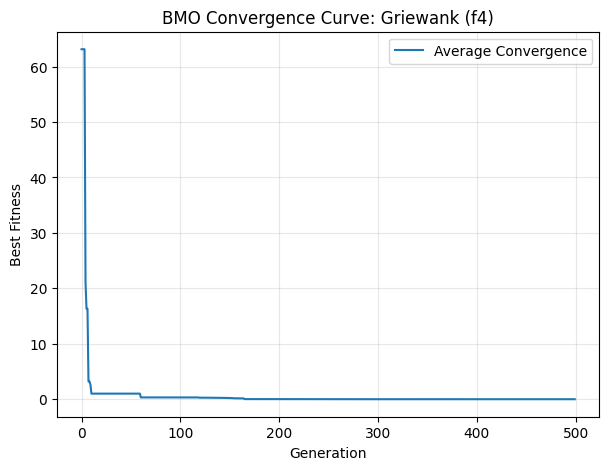


Running 30 runs for Six-Hump Camel (f5)...
Six-Hump Camel (f5) Mean Fitness: -1.0316284534898774
Six-Hump Camel (f5) Std Dev     : 4.440892098500626e-16


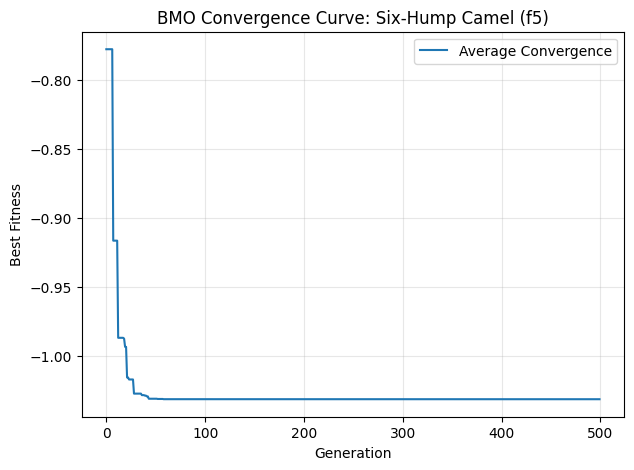


Running 30 runs for Branin (f6)...
Branin (f6) Mean Fitness: 0.39788735772973816
Branin (f6) Std Dev     : 0.0


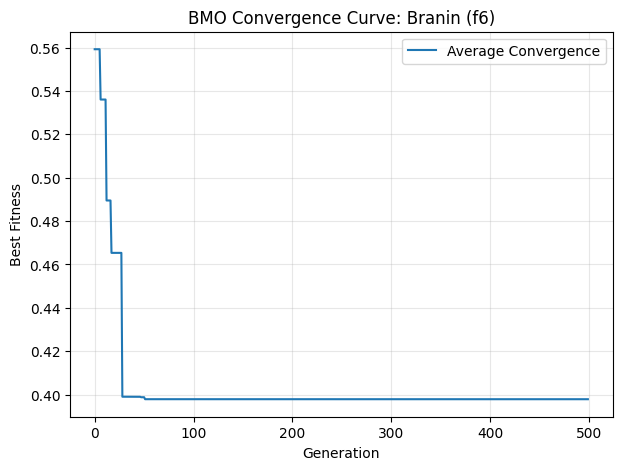

In [11]:
evaluate_and_plot("Sphere (f1)", sphere, 30, sphere_bounds)
evaluate_and_plot("Absolute Sum & Absolute Product (f2)", asap, 30, asap_bounds)
evaluate_and_plot("Rastrigin (f3)", rastrigin, 30, rastrigin_bounds)
evaluate_and_plot("Griewank (f4)", griewank, 30, griewank_bounds)

evaluate_and_plot("Six-Hump Camel (f5)", shc, 2, shc_bounds)
evaluate_and_plot("Branin (f6)", branin, 2, branin_bounds)


#### Running 30 times over

In [10]:
# def run_multiple_WOA(obj_fn, dim, bounds, runs=30):
#     ''' This function allows for the algorithms to run for 30 times and
#         produces an averaged result of the best values
        
#         Parameters
#             obj_fn: Objective Function
#             dim: Dimensions
#             Bounds: Bounds for function, defined above
#             Runs: Amount of runs, set to 30
        
#         Returns:
#             Mean of best values: average of best fitness values from 30 runs
#             Std. Dev of best values: standard deviation of best values
#             best_values: list of best values from each run
#             avg_history: average convergence curve
#             std_history: standard deviation of convergence curves'''
    
#     best_values = []
#     histories = []

#     # bounds, from above
#     lb, ub = bounds  


#     for r in range(runs):
#         best_pos, history = WOA(
#             f=obj_fn,
#             dim=dim,
#             lb=lb,
#             ub=ub,
#             num_whales=30,
#             max_iter=500
#         )

#         final_best = history[-1]        # last fitness value
#         best_values.append(final_best)
#         histories.append(history)

#     histories = np.array(histories)     # shape = (runs, max_iter)

#     avg_history = histories.mean(axis=0)
#     std_history = histories.std(axis=0)

#     return (
#         np.mean(best_values),
#         np.std(best_values),
#         best_values,
#         avg_history,
#         std_history
#     )
